# EDA: Predicción Temprana del Alzheimer

#### **Objetivo:** Predecir a partir de datos clínicos, cognitivos y demográficos si un paciente desarrollará o presenta signos tempranos del deterioro cognitivo asociado al Alzheimer

## 1. Configuración e Inspección Inicial

### 1.1 Carga de librerías y datos

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

alzheimer_data = pd.read_csv('../data/raw/alzheimers_disease_data.csv')

print(alzheimer_data.head())

   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confusion  Disorientation  \
0     

### 1.2 Overview rápido de los datos

In [5]:
alzheimer_data.info()
alzheimer_data.describe()
alzheimer_data['Diagnosis'].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64  
 14  Dep

Diagnosis
0    0.646347
1    0.353653
Name: proportion, dtype: float64

> **nota:** El dataset ya viene previamente limpio. De las 35 columnas sólo 2 no son útiles para el análisis (PacientID y DoctorInCharge). Además hay una desproporción leve en los datos de Diagnosis siendo un 65/35 (hay más pacientes sin alzheimer que aquellos que sí).

## 2. Análisis Univariado

#### 2. 1 Características binarias

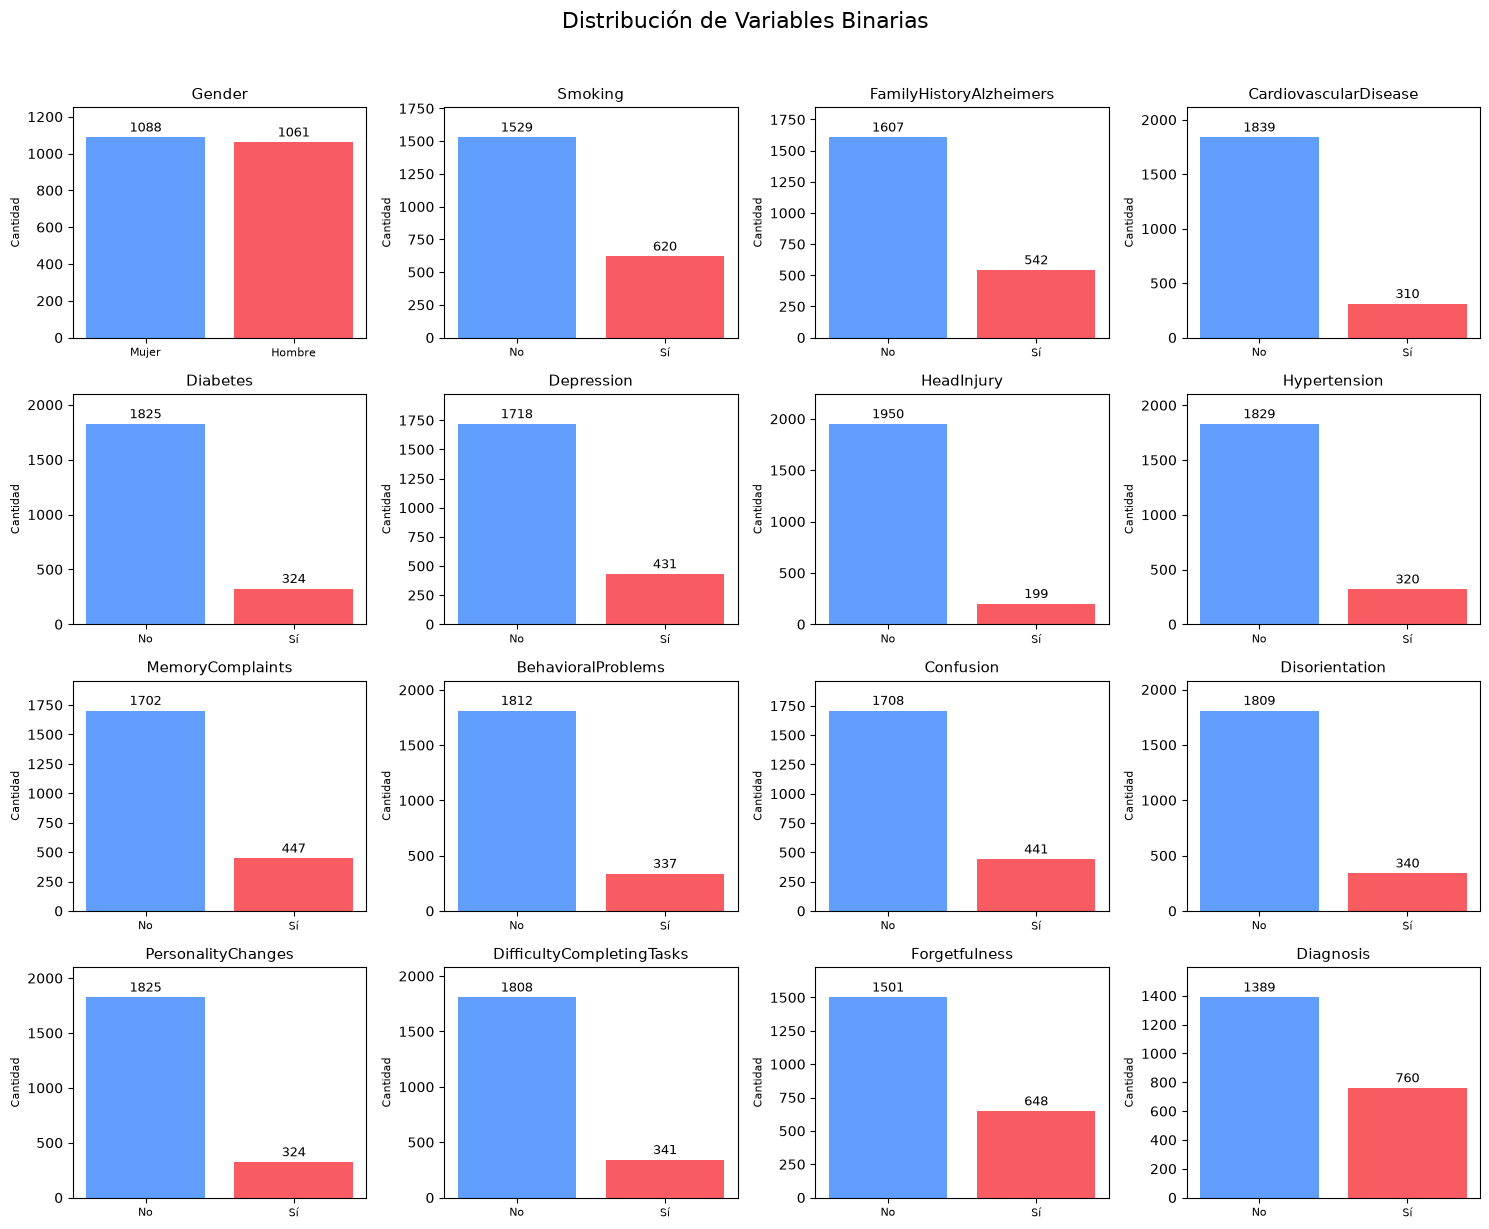

In [ ]:
alzheimer_data_clean = alzheimer_data.drop(columns=['PatientID','DoctorInCharge'])

binary_features = [
    'Gender', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
    'Diabetes', 'Depression', 'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness',
    'Diagnosis'
]

plt.figure(figsize=(15, 12))
plt.suptitle("Distribución de Variables Binarias", fontsize=16, y=1.02)

colors = ["#619EFB", "#F85B61"]

for i, feature in enumerate(binary_features):
    plt.subplot(4, 4, i+1) 
    counts = alzheimer_data_clean[feature].value_counts()
    bars = plt.bar(counts.index.astype(str), counts.values, color=colors)
    
    # Agregamos el número exacto sobre cada barra
    plt.bar_label(bars, padding=2, fontsize=9)
    
    plt.title(feature, fontsize=11)
    plt.ylabel("Cantidad", fontsize=8)

    if feature == 'Gender':
        plt.xticks([0, 1], ['Mujer', 'Hombre'], fontsize=8)
    else:
        plt.xticks([0, 1], ['No', 'Sí'], fontsize=8)
    plt.ylim(0, max(counts.values) * 1.15)  # Espacio para que el texto sobre la barra no se corte

# 3. Ajustamos espacios entre subtítulos
plt.tight_layout()
plt.show()

#### 2.2 Características numéricas 

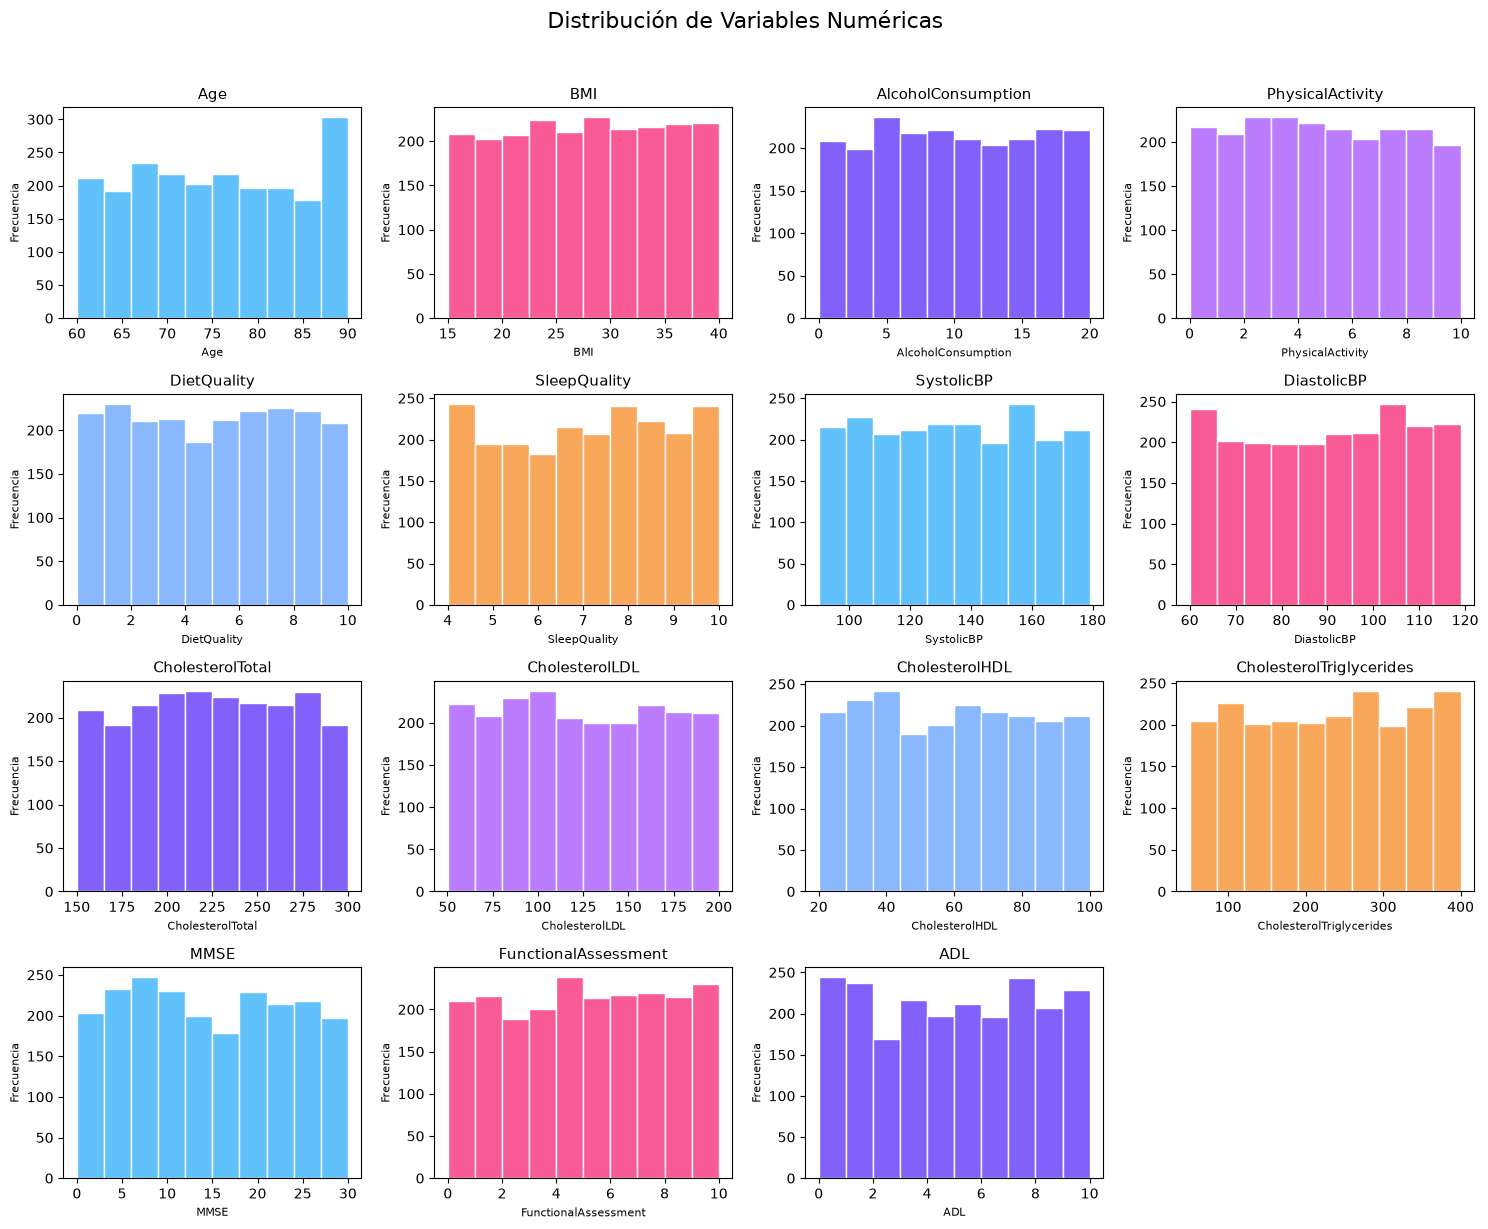

In [ ]:
numeric_features = [
     'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
    'SleepQuality', 'SystolicBP', 'DiastolicBP',
    'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides',
    'MMSE', 'FunctionalAssessment', 'ADL'
]

plt.figure(figsize=(15, 12))
plt.suptitle("Distribución de Variables Numéricas", fontsize=16, y=1.02)

colors = ["#61C2FB", "#F85B95", "#8261FB", "#BB7CFF", "#8AB8FC", "#F8A75B"]

for i, feature in enumerate(numeric_features):
    plt.subplot(4, 4, i+1) 
    histogram = plt.hist(alzheimer_data_clean[feature], bins=10, color=colors[i % len(colors)], edgecolor='white')
    
    plt.title(feature, fontsize=11)
    plt.ylabel("Frecuencia", fontsize=8)
    plt.xlabel(feature, fontsize=8)

plt.tight_layout()
plt.show()

### 2.3 Características Multicategoricas

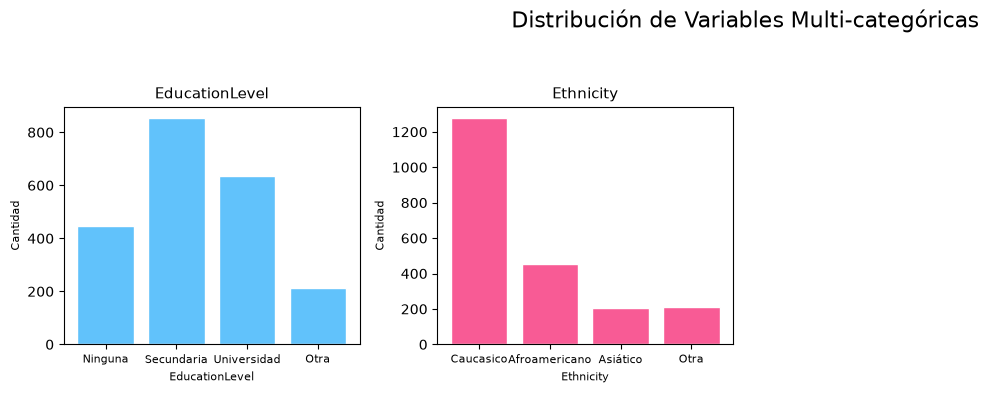

In [ ]:
multicategory_features = ['EducationLevel', 'Ethnicity']

plt.figure(figsize=(15, 12))
plt.suptitle("Distribución de Variables Multi-categóricas", fontsize=16, y=1.02)

colors = ["#61C2FB", "#F85B95", "#8261FB", "#BB7CFF", "#8AB8FC", "#F8A75B"]

for i, feature in enumerate(multicategory_features):
    plt.subplot(4, 4, i+1) 
    bar = plt.bar(alzheimer_data_clean[feature].value_counts().index, alzheimer_data_clean[feature].value_counts().values, color=colors[i % len(colors)], edgecolor='white')
    
    plt.title(feature, fontsize=11)
    plt.ylabel("Cantidad", fontsize=8)
    if feature == 'EducationLevel':
        plt.xticks([0,1,2,3], ['Ninguna', 'Secundaria', 'Universidad', 'Otra'], fontsize=8)
    elif feature == 'Ethnicity':
        plt.xticks([0,1,2,3], ['Caucasico', 'Afroamericano', 'Asiático', 'Otra'], fontsize=8)
    plt.xlabel(feature, fontsize=8)

# 3. Ajustamos espacios entre subtítulos
plt.tight_layout()
plt.show()


## 3. Análisis Bivariable

### 3.1 Diagnóstico VS Características Categóricas

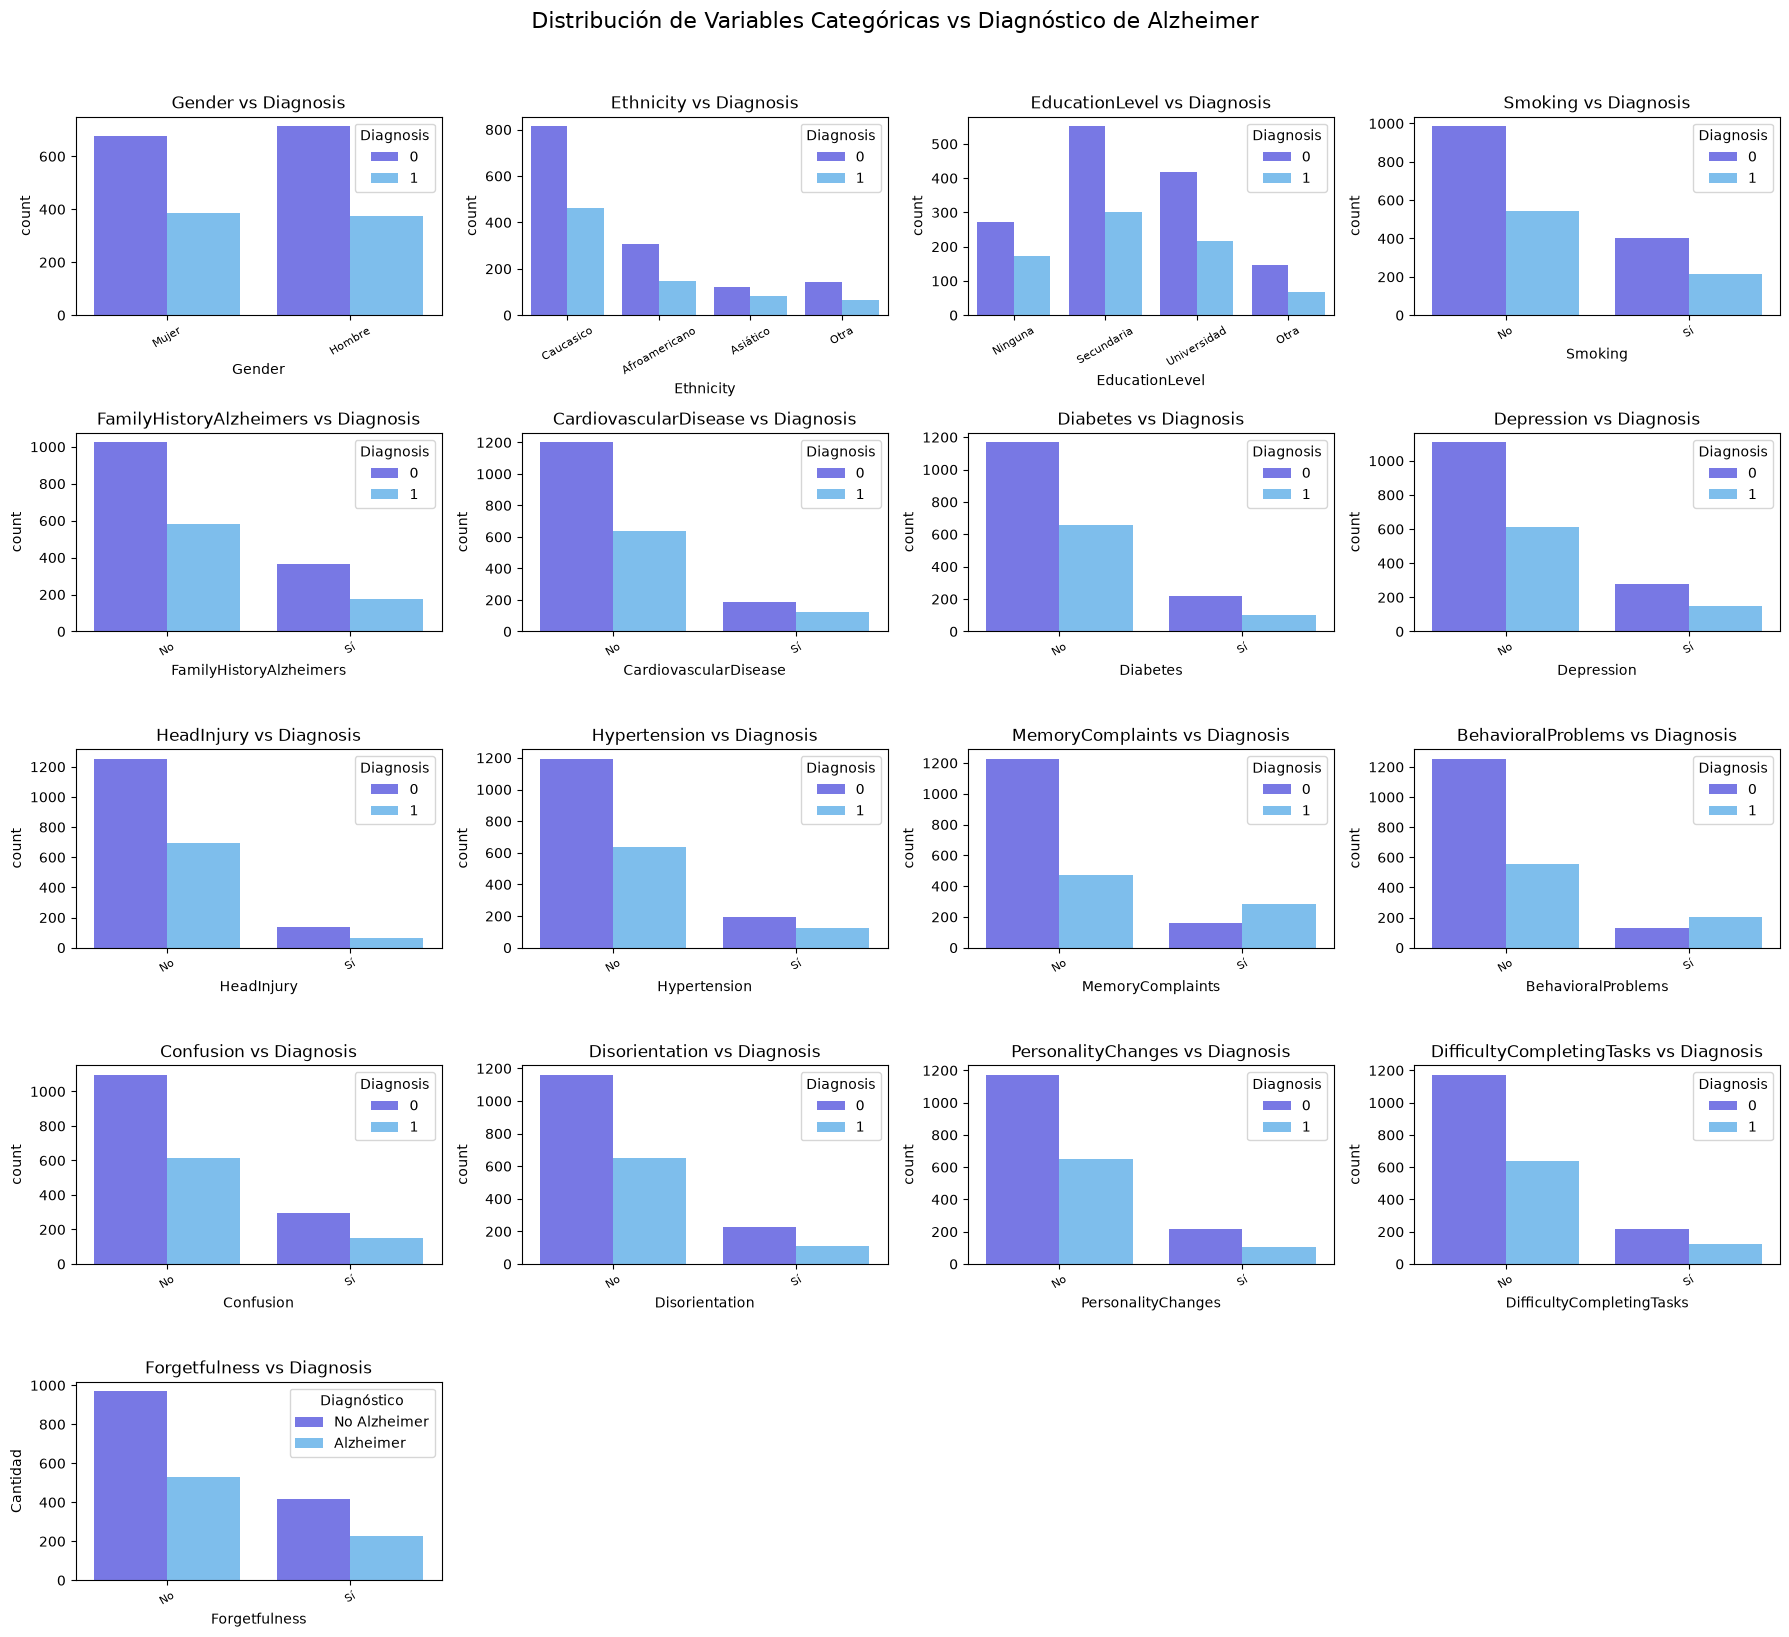

In [ ]:
categorical_features = []

for columna in alzheimer_data_clean.columns:
  if columna != 'Diagnosis':
    # Si la columna tiene 5 o menos valores distintos, la guardamos
    if alzheimer_data_clean[columna].nunique() <= 5:
      categorical_features.append(columna)

map = {
    'Gender': ['Mujer', 'Hombre'],
    'EducationLevel': ['Ninguna', 'Secundaria', 'Universidad', 'Otra'],
    'Ethnicity': ['Caucasico', 'Afroamericano', 'Asiático', 'Otra'],
}

plt.figure(figsize=(18, 16))
plt.suptitle('Distribución de Variables Categóricas vs Diagnóstico de Alzheimer', fontsize=16, y=1.02)

n_cols = 4
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

for i, feature in enumerate(categorical_features, 1):
  plt.subplot(n_rows, n_cols, i)
  sns.countplot(data=alzheimer_data_clean, x=feature, hue='Diagnosis', palette=["#6666F6", "#6CC1FE"])
  plt.title(f'{feature} vs Diagnosis', fontsize=12)

  labels = map.get(feature, ['No', 'Sí'])
  plt.xticks(ticks=range(len(labels)), labels=labels, fontsize=8, rotation=30)

plt.ylabel('Cantidad')
plt.legend(title='Diagnóstico', labels=["No Alzheimer", "Alzheimer"])

plt.tight_layout()
plt.show()

### 3.2 Diagnóstico VS Categorías Numéricas

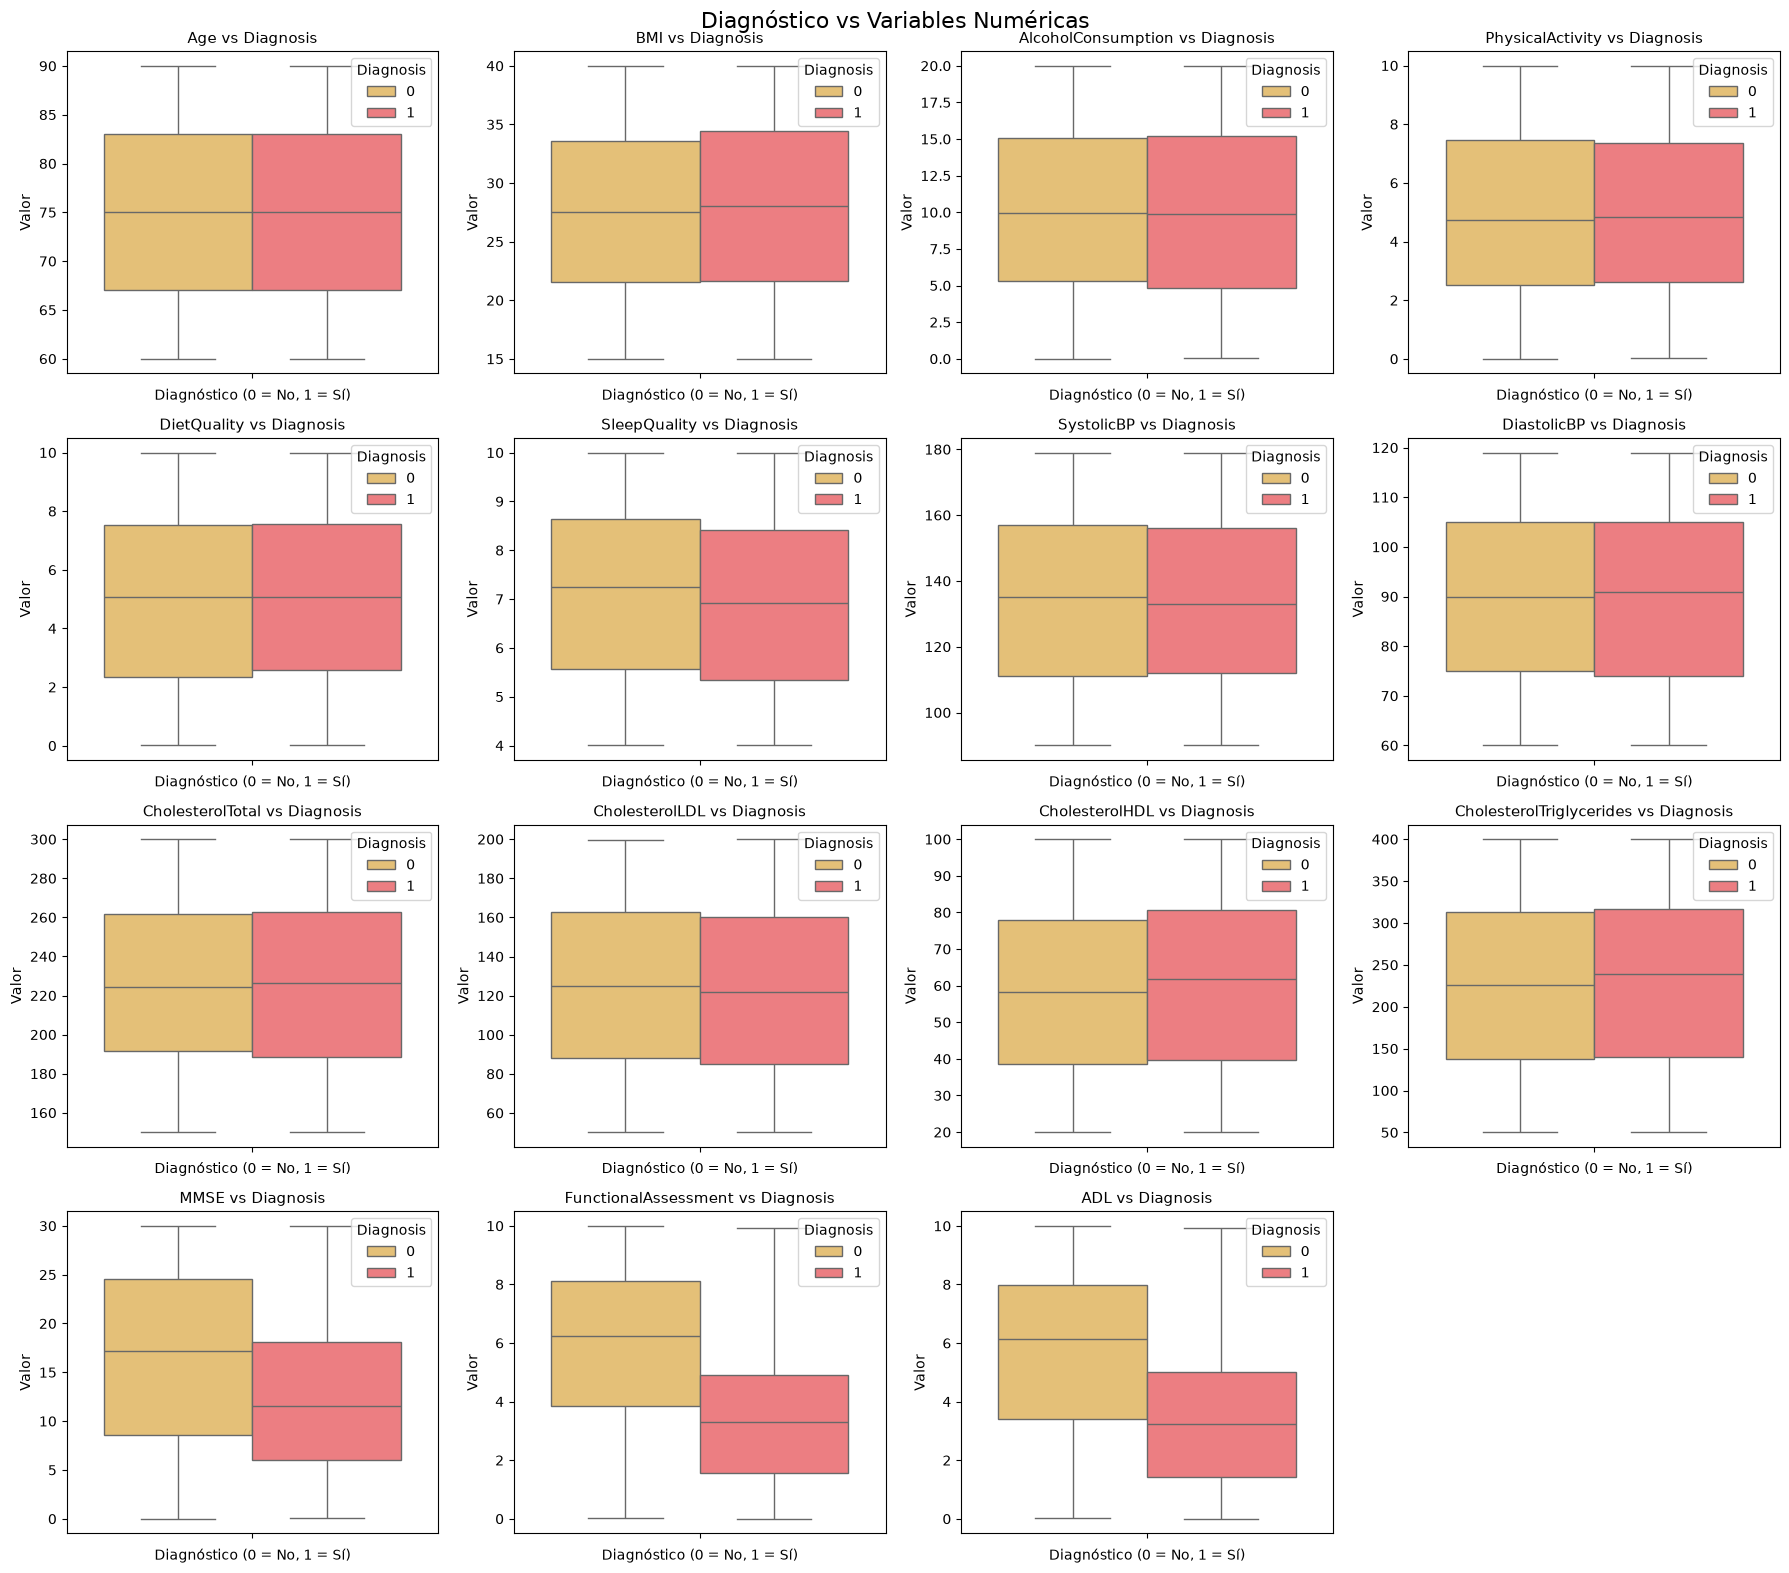

In [62]:
import math
numeric_features = []

for col in alzheimer_data_clean.columns:
  if col != 'Diagnosis' and alzheimer_data_clean[col].nunique() > 5:
    numeric_features.append(col)

graphics = len(numeric_features)
columns = 4
filas = math.ceil(graphics / columns)  # Redondea hacia arriba las filas

plt.figure(figsize=(18, 16))
plt.suptitle('Diagnóstico vs Variables Numéricas', fontsize=16)

for position, column in enumerate(numeric_features, start=1):
  plt.subplot(filas, columns, position)

  sns.boxplot(data=alzheimer_data_clean, hue='Diagnosis', y=column, palette=["#F6C666", "#FE6C71"])

  plt.title(f'{column} vs Diagnosis', fontsize=11)
  plt.xlabel('Diagnóstico (0 = No, 1 = Sí)')
  plt.ylabel('Valor')

plt.tight_layout()
plt.show()

## 4. Hallazgos

### 4.1 Análisis Univariable

#### **De las variables binarias** 
- El dataset se encuentra balanceado en cuanto al género.
- Hay un desbalance leve en la variable *Diagnosis* de 65/35 (más a favor que en contra) en los datos sin emabrgo, sí permite que se entrene bien el modelo.
- La gran mayoría de las variables clínicas, sociodemográficas y de comportamiento presentan un desbalance en el estado negativo (diagnóstico positivo).
- Las afecciones físicas tienen menor presencia en la muestra.
- Síntomas neuropsiquiátricos y factores familiares tienen una presencia moderada en la muestra.

#### **De las variables numéricas**
Los histogramas reflejan una distribución bastante uniforme en las variables.

### 4.2 Análisis Bivariable

#### **De las variables categóricas vs el diagnóstico**
Solo dos variables muestran un cambio drástico en la proporción de diagnósticos positivos cuando están presentes, MemoryComplaints y BehavioralProblems.

#### **De las variables numéricas vs el diagnóstico**
De todas las características sólo 3 (MMSE, ADL, FunctionalAssessment) muestran correlaciones negativas, es decir, entre más bajos sus valores más probabilidad hay de que el paciente tenga Alzheimer.